# Lesson 8: Clustering (K-Means)

## K-Means Algorithm, Elbow Method, and Silhouette Score

In this notebook we will:
- Implement K-Means clustering
- Find optimal k using elbow method and silhouette score
- Visualize clusters with PCA
- Interpret cluster characteristics

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.style.use('ggplot')
%matplotlib inline

## 1. K-Means on Iris Dataset

In [2]:
iris = sns.load_dataset('iris')
X = iris.drop('species', axis=1)
y = iris['species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
iris['cluster'] = kmeans.fit_predict(X_scaled)

# Compare with true labels
print(pd.crosstab(iris['species'], iris['cluster']))

cluster      0   1   2
species               
setosa       0  50   0
versicolor  39   0  11
virginica   14   0  36


## 2. Elbow Method and Silhouette

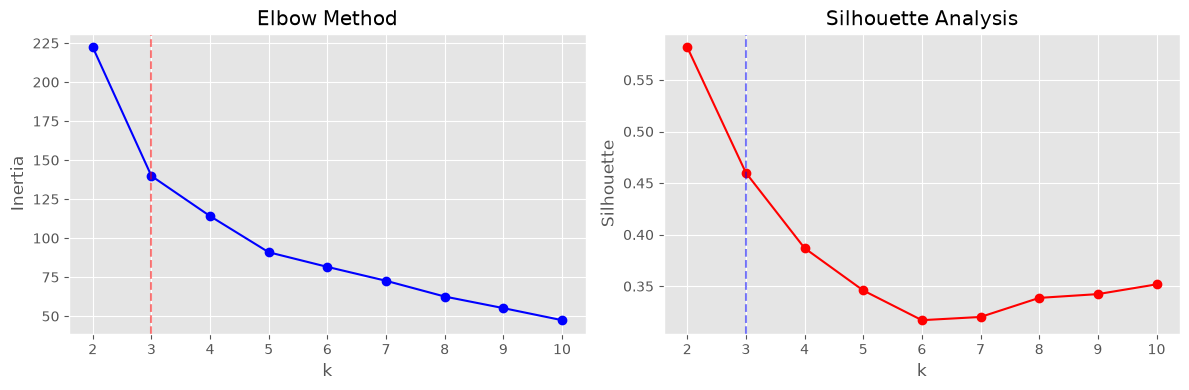

In [3]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].axvline(3, color='red', linestyle='--', alpha=0.5)

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
axes[1].set_title('Silhouette Analysis')
axes[1].axvline(3, color='blue', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Visualize Clusters with PCA

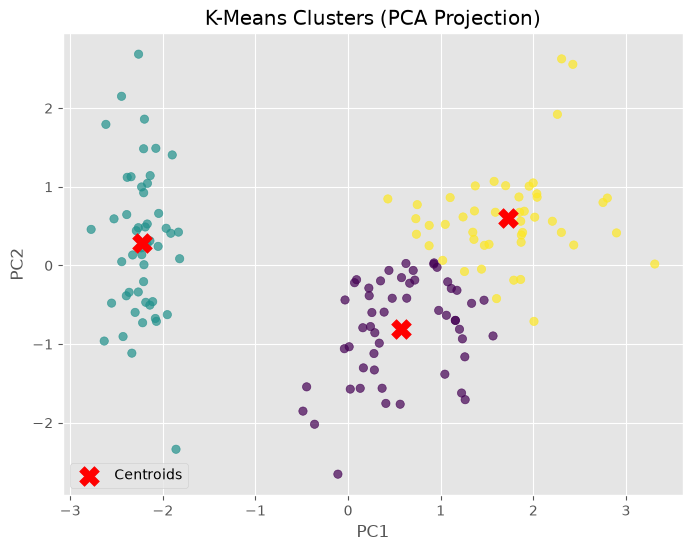

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=iris['cluster'], cmap='viridis', alpha=0.7)
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters (PCA Projection)')
plt.legend()
plt.show()

## 4. Customer Segmentation Example

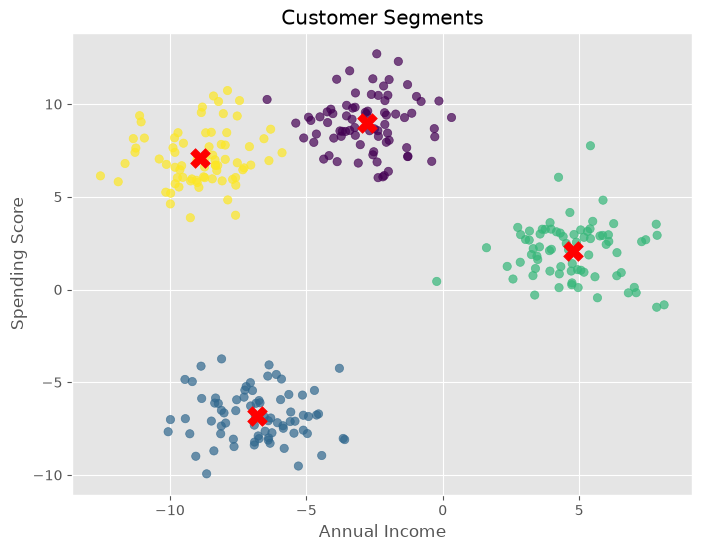

Segment Profiles:
         annual_income  spending_score
segment                               
0            -2.768479        8.961130
1            -6.808714       -6.805631
2             4.757368        2.076110
3            -8.891194        7.100114


In [5]:
from sklearn.datasets import make_blobs

X_cust, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.5, random_state=42)
customer_df = pd.DataFrame(X_cust, columns=['annual_income', 'spending_score'])

kmeans_cust = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['segment'] = kmeans_cust.fit_predict(X_cust)

plt.figure(figsize=(8, 6))
plt.scatter(X_cust[:, 0], X_cust[:, 1], c=customer_df['segment'], cmap='viridis', alpha=0.7)
plt.scatter(kmeans_cust.cluster_centers_[:, 0], kmeans_cust.cluster_centers_[:, 1],
            c='red', marker='X', s=200)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()

print("Segment Profiles:")
print(customer_df.groupby('segment').mean())

## Exercises

1. Load penguins, standardize numeric features, apply K-Means with k=3. Compare with actual species.
2. Compute silhouette scores for k=2..8 on iris and find optimal k.
3. Generate make_blobs with 4 centers and test elbow + silhouette.